In [1]:
import time
from ip import *
import numpy as np
import networkx as nx
from scipy import ndimage
import matplotlib.pyplot as plt
from skimage.filters import threshold_triangle
from skimage.util import img_as_ubyte, img_as_float
from skimage.morphology import skeletonize

In [2]:
volumeOP1 = img_as_float(load_tif_stack("./OlfactoryProjectionFibers/ImageStacks/OP_1"))
volumeOP2 = img_as_float(load_tif_stack("./OlfactoryProjectionFibers/ImageStacks/OP_2"))
volumeOP3 = img_as_float(load_tif_stack("./OlfactoryProjectionFibers/ImageStacks/OP_3"))
volumeOP4 = img_as_float(load_tif_stack("./OlfactoryProjectionFibers/ImageStacks/OP_4"))
volumeOP5 = img_as_float(load_tif_stack("./OlfactoryProjectionFibers/ImageStacks/OP_5"))
volumeOP6 = img_as_float(load_tif_stack("./OlfactoryProjectionFibers/ImageStacks/OP_6"))
volumeOP7 = img_as_float(load_tif_stack("./OlfactoryProjectionFibers/ImageStacks/OP_7"))
volumeOP8 = img_as_float(load_tif_stack("./OlfactoryProjectionFibers/ImageStacks/OP_8"))
volumeOP9 = img_as_float(load_tif_stack("./OlfactoryProjectionFibers/ImageStacks/OP_9"))

In [3]:
rootOP_1 = (30.979,429.04,0)
rootOP_2 = (0.72501,391.08,25)
rootOP_3 = (93.742,179,38)
rootOP_4 = (128.2,504.37,0.3)
rootOP_5 = (185.7,264.02,33)
rootOP_6 = (15.074,412.01,10)
rootOP_7 = (119.76,215.98,39)
rootOP_8 = (118.64,181.34,55)
rootOP_9 = (64.56,364.47,4)

In [4]:
kernel1 = np.array(
    [[1 / 16, 1 / 8, 1 / 16], [1 / 8, 1 / 4, 1 / 8], [1 / 16, 1 / 8, 1 / 16]]
)

kernel1 = kernel1 / np.sum(kernel1)
kernel2 = np.array(
    [
        [1 / 256, 1 / 64, 3 / 128, 1 / 64, 1 / 256],
        [1 / 64, 1 / 16, 3 / 32, 1 / 16, 1 / 64],
        [3 / 128, 3 / 32, 9 / 64, 3 / 32, 3 / 128],
        [1 / 64, 1 / 16, 3 / 32, 1 / 16, 1 / 64],
        [1 / 256, 1 / 64, 3 / 128, 1 / 64, 1 / 256],
    ]
)

kernel2 = kernel2 / np.sum(kernel2)

In [5]:
vol3d = img_as_ubyte(volumeOP4.copy())
curr_root = rootOP_4

In [6]:
image3d_sharp = img_as_ubyte(convolve3d(vol3d, kernel2))

In [7]:
image3d_min_3 = img_as_ubyte(ndimage.minimum_filter(image3d_sharp, 3))

In [8]:
thresh_tri1 = threshold_triangle(image3d_min_3)
binary_tri1 = img_as_ubyte(image3d_min_3 > thresh_tri1)
seg1 = img_as_ubyte(segment(image3d_min_3, binary_tri1))

In [9]:
skel1 = img_as_ubyte(skeletonize(binary_tri1))

In [10]:
image3d_min_2 = img_as_ubyte(ndimage.minimum_filter(image3d_sharp, 2))

In [11]:
thresh_tri2 = threshold_triangle(image3d_min_2)
binary_tri2 = img_as_ubyte(image3d_min_2 > thresh_tri2)
seg2 = img_as_ubyte(segment(image3d_min_2, binary_tri2))

In [12]:
skel2 = img_as_ubyte(skeletonize(binary_tri2))

In [13]:
# simple_imshow(
#     [
#         # projection2d(vol3d, "max"),
#         # projection2d(image3d_sharp, "max"),
#         # projection2d(image3d_min_3, "max"),
#         # projection2d(image3d_min_2, "max"),
#         # projection2d(binary_tri1, "max"),
#         # projection2d(binary_tri2, "max"),
#         projection2d(seg1, "max"),
#         projection2d(seg2, "max"),
#         projection2d(skel1, "max"),
#         projection2d(skel2, "max"),

#     ]
# )

In [14]:
root1 = find_nearest_foreground_point(skel1, curr_root)
root2 = find_nearest_foreground_point(skel2, curr_root)

In [15]:
graph = Graph(skel1)
graph.set_root(root1)
graph.create_graph()
root = list(graph.get_root())[::-1]
g_root = (0.72501,391.08,25)
print(f"OP_1 GOLD STANDARD ROOT: {g_root}\nTEST ROOT: {tuple(root)}")

>> Graph created
OP_1 GOLD STANDARD ROOT: (0.72501, 391.08, 25)
TEST ROOT: (np.int64(129), np.int64(501), np.int64(2))


In [16]:
mst_labeled = graph.apply_dfs_and_label_nodes()

>> Minimum Spanning Tree Generated
>> Minimum Spanning Tree length: 1186
>> Depth-First search and labeling complete


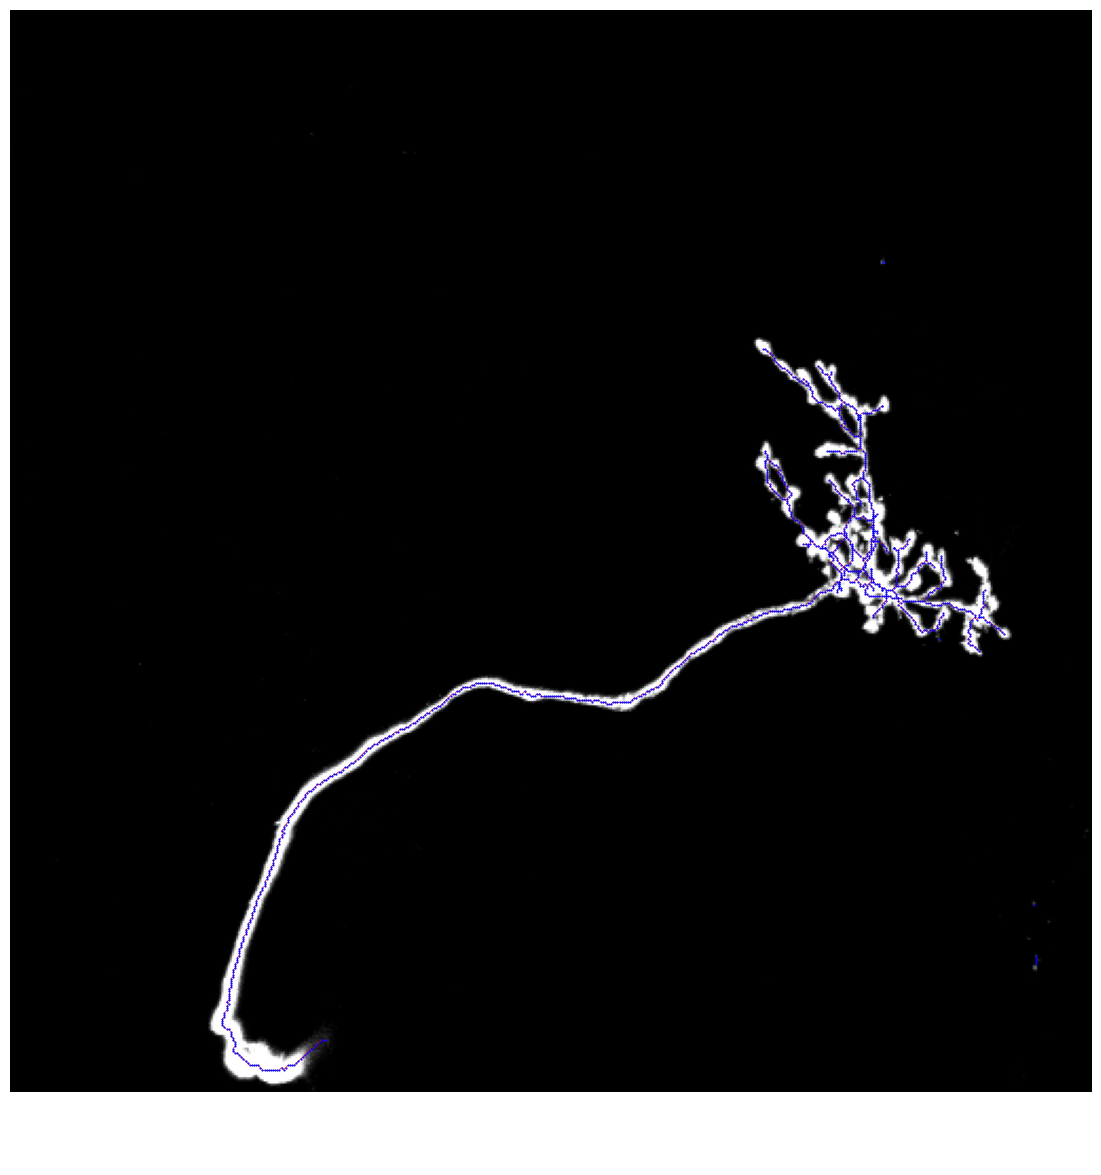

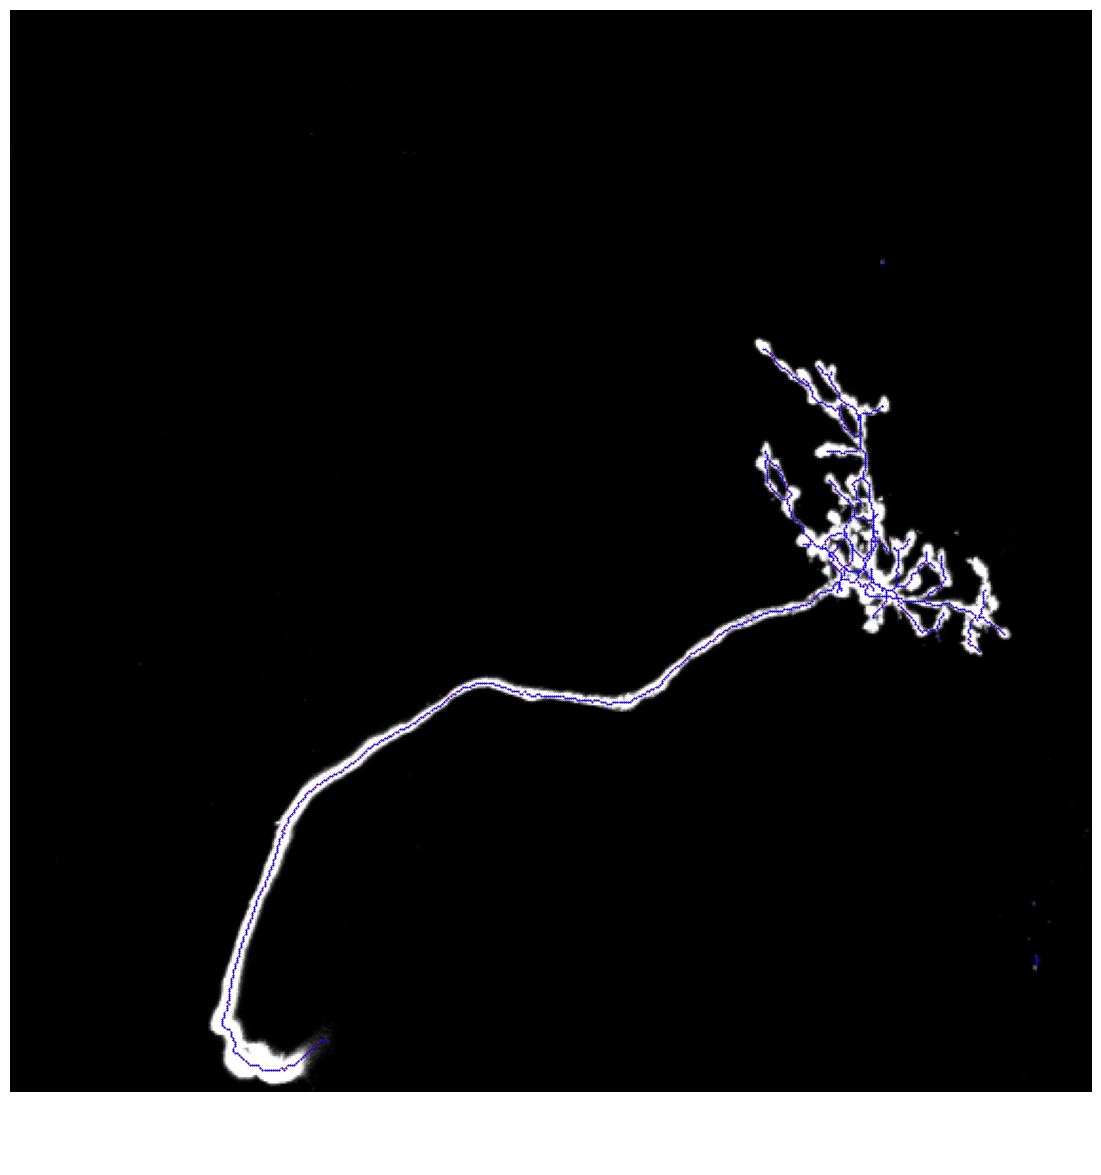

In [17]:
visualize_medial_graph(vol3d, graph.get_graph())
visualize_medial_graph(vol3d, mst_labeled)

In [18]:
# graph.save_to_swc(mst_labeled,"./Test/OP_1test1.swc")